In [1]:
import glob
import xgboost as xgb
import numpy as np

def load_xgb_models(model_path_or_pattern):
    """
    model_path_or_pattern:
      - "xgb_final.json"  -> 返回 [Booster]
      - "xgb_models/xgb_fold*.json" -> 返回 多个 Booster
    """
    paths = sorted(glob.glob(model_path_or_pattern))
    if len(paths) == 0:
        # 不是 pattern，就当成单文件
        paths = [model_path_or_pattern]

    models = []
    for p in paths:
        b = xgb.Booster()
        b.load_model(p)
        models.append(b)
    return models
models_A = load_xgb_models("xgb_models_sntvariable_deltaR_removed/xgb_fold0.json")

In [2]:
booster = models_A[0]

importance = booster.get_score(importance_type='gain')
print(importance)

{'f0': 18.2269344329834, 'f1': 0.6205528974533081, 'f2': 29.487977981567383, 'f3': 1.1447283029556274, 'f4': 0.20438195765018463, 'f5': 0.27202108502388, 'f6': 0.6455785632133484, 'f7': 13.33193588256836, 'f8': 0.2614797353744507, 'f9': 0.21936991810798645, 'f10': 0.5321429371833801, 'f11': 6.230433464050293, 'f12': 1.2234606742858887, 'f13': 3.7843289375305176, 'f14': 6.026298522949219}


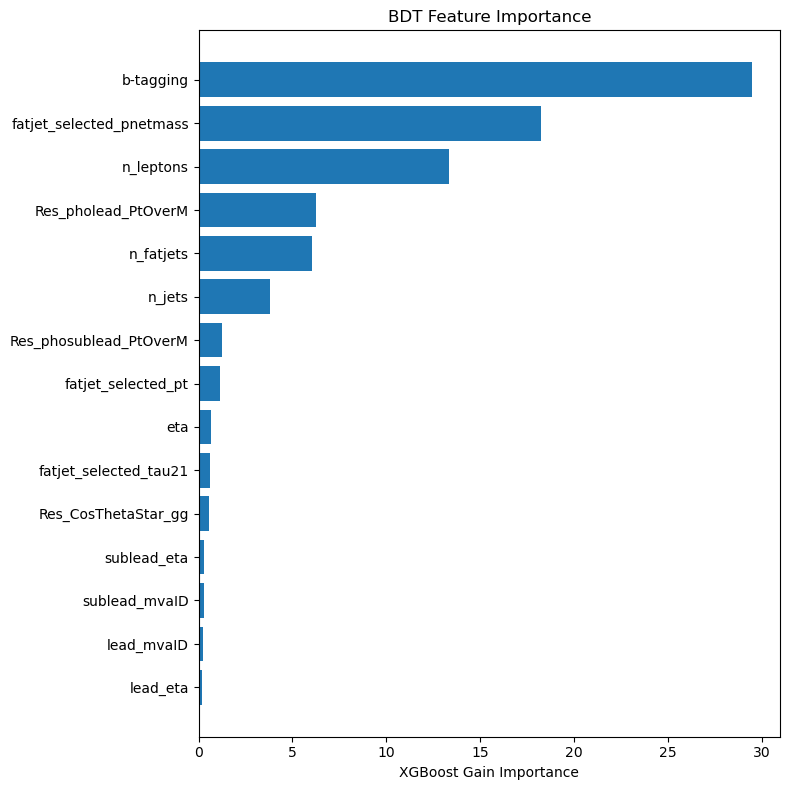

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# BDT_variables = ['eta',
#  'lead_mvaID',
#  'lead_sigmaE_over_E',
#  'lepton1_mvaID',
#  'lepton1_pfIsoId',
#  'lepton1_pt',
#  'Res_CosThetaStar_CS',
#  'Res_CosThetaStar_gg',
#  #'pt',
#  'puppiMET_pt',
#  'puppiMET_sumEt',
#  'sublead_mvaID',
#  'sublead_sigmaE_over_E',
#  'b-tagging',
#  'fatjet_selected_pnetmass',
#  'fatjet_selected_pt',
#  'deltaR_g1_fj',
#  'deltaR_g2_fj',
#  'fatjet_selected_eta',
#  #'Res_DNNpair_HHbbggCandidate_mass',
#  #'Res_DNNpair_HHbbggCandidate_pt',
#  #'Res_DNNpair_HHbbggCandidate_eta',
#  'fatjet_selected_tau21',
#  'fatjet_selected_tau32']
BDT_variables = [    
    'fatjet_selected_pnetmass',
    'fatjet_selected_tau21',
    'b-tagging',
    'fatjet_selected_pt',
    'lead_eta',
    'sublead_eta',
    'eta',
    'n_leptons',
    'sublead_mvaID',
    'lead_mvaID',
    'Res_CosThetaStar_gg',
    'Res_pholead_PtOverM',
    'Res_phosublead_PtOverM',
    'n_jets',
    'n_fatjets',

]
# 读取 importance
score = booster.get_score(importance_type='gain')

# 初始化 importance
importance = np.zeros(len(BDT_variables))

for k,v in score.items():
    idx = int(k[1:])
    importance[idx] = v

# 排序
order = np.argsort(importance)

plt.figure(figsize=(8,8))

plt.barh(
    np.array(BDT_variables)[order],
    importance[order]
)

plt.xlabel("XGBoost Gain Importance")
plt.title("BDT Feature Importance")

plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import pickle
import mplhep as hep
import matplotlib.pyplot as plt
import yaml
import math
from tqdm import tqdm
plt.style.use(hep.style.CMS)
import itertools
import os
import importlib.util
import sys
from array import array
import matplotlib.colors as mcolors
import gc
from typing import Iterable, Tuple, Dict, Any, Optional, List
import glob

In [5]:
with open("SnT_variable_deltaRremoved_NonRes.pkl", 'rb') as handle:
    df_all =  pd.read_pickle(handle)

In [6]:
df_bkg = df_all[(df_all["Type"]==0)].copy()

In [7]:
df_TT = df_all[df_all["Type"]==1].copy()

In [8]:
len(df_TT)

105736

In [9]:
len(df_bkg)

370069

In [10]:
with open("SnT_variable_deltaRremoved_Signal.pkl", 'rb') as handle:
    df_sig =  pd.read_pickle(handle)

In [11]:
df_sig = df_sig[df_sig["b-tagging"]>0].copy()

In [14]:
num_sig = df_sig["eventWeight"].sum()

In [57]:
#print( df_sig[df_sig["b-tagging"]<=1]["eventWeight"].sum() / num_sig , df_sig[df_sig["b-tagging"]<=2]["eventWeight"].sum() / num_sig, 
#       df_sig[df_sig["b-tagging"]<=3]["eventWeight"].sum() / num_sig,df_sig[df_sig["b-tagging"]<=4]["eventWeight"].sum() / num_sig)

In [58]:
# with open("Boost_HighStat_2223.pkl", 'rb') as handle:
#     df_2223_4 =  pd.read_pickle(handle)

In [59]:
# with open("Boost_HighStat_2223_5.pkl", 'rb') as handle:
#     df_2223_5 =  pd.read_pickle(handle)

In [60]:
#df_2223 = pd.concat([df_2223_4,df_2223_5],ignore_index=True)

In [61]:
# with open("Boost_HighStat_2024.pkl", 'rb') as handle:
#     df_2024 =  pd.read_pickle(handle)

In [62]:
df_2223["b-tagging"] = 0
df_2223.loc[df_2223["fatjet_selected_particleNet_XbbVsQCD"]>=0.96,"b-tagging"] = 5
df_2223.loc[(df_2223["fatjet_selected_particleNet_XbbVsQCD"]>=0.925) & 
      (df_2223["fatjet_selected_particleNet_XbbVsQCD"]<0.96)  ,"b-tagging"] = 4
df_2223.loc[(df_2223["fatjet_selected_particleNet_XbbVsQCD"]>=0.89) & 
      (df_2223["fatjet_selected_particleNet_XbbVsQCD"]<0.925)  ,"b-tagging"] = 3
df_2223.loc[(df_2223["fatjet_selected_particleNet_XbbVsQCD"]>=0.83) & 
      (df_2223["fatjet_selected_particleNet_XbbVsQCD"]<0.89)  ,"b-tagging"] = 2
df_2223.loc[(df_2223["fatjet_selected_particleNet_XbbVsQCD"]>=0.4) & 
      (df_2223["fatjet_selected_particleNet_XbbVsQCD"]<0.83)  ,"b-tagging"] = 1

/tmp/ipykernel_27046/1896627118.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_2223["b-tagging"] = 0


In [63]:
df_2024["b-tagging"] = 0
df_2024.loc[ df_2024["fatjet_selected_globalParT3_XbbVsQCD"]>=0.96,"b-tagging"] = 5
df_2024.loc[( df_2024["fatjet_selected_globalParT3_XbbVsQCD"]>=0.91) & 
      ( df_2024["fatjet_selected_globalParT3_XbbVsQCD"]<0.96)  ,"b-tagging"] = 4
df_2024.loc[( df_2024["fatjet_selected_globalParT3_XbbVsQCD"]>=0.86) & 
      ( df_2024["fatjet_selected_globalParT3_XbbVsQCD"]<0.91)  ,"b-tagging"] = 3
df_2024.loc[( df_2024["fatjet_selected_globalParT3_XbbVsQCD"]>=0.8) & 
      ( df_2024["fatjet_selected_globalParT3_XbbVsQCD"]<0.86)  ,"b-tagging"] = 2
df_2024.loc[( df_2024["fatjet_selected_globalParT3_XbbVsQCD"]>=0.57) & 
      ( df_2024["fatjet_selected_globalParT3_XbbVsQCD"]<0.8)  ,"b-tagging"] = 1

/tmp/ipykernel_27046/2170398663.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_2024["b-tagging"] = 0


In [64]:
def cut_sample(df):
    df.query("`b-tagging`>0", inplace=True)
    df.query("`fatjet_selected_tau21`<0.75", inplace = True)
    df.query("`fatjet_selected_pt`>300", inplace = True)
    df.query("`fatjet_selected_pnetmass`>30", inplace = True)

In [65]:
cut_sample(df_2223)
cut_sample(df_2024)

In [66]:
Bkg_event_variables = ["run","lumi","event","weight", "mass"]

In [67]:
df_2223['lead_sigmaE_over_E'] = df_2223['lead_energyErr'] / (df_2223['lead_pt'] * np.cosh(df_2223['lead_eta']))
df_2223['sublead_sigmaE_over_E'] = df_2223['sublead_energyErr'] / (df_2223['lead_pt'] * np.cosh(df_2223['lead_eta']))

In [68]:
df_2024['lead_sigmaE_over_E'] = df_2024['lead_energyErr'] / (df_2024['lead_pt'] * np.cosh(df_2024['lead_eta']))
df_2024['sublead_sigmaE_over_E'] = df_2024['sublead_energyErr'] / (df_2024['lead_pt'] * np.cosh(df_2024['lead_eta']))

In [69]:
df_bkg = pd.concat([df_2223[BDT_variables+Bkg_event_variables],df_2024[BDT_variables+Bkg_event_variables]] , ignore_index=True)

In [70]:
df_bkg["eventWeight"] = df_bkg["weight"]

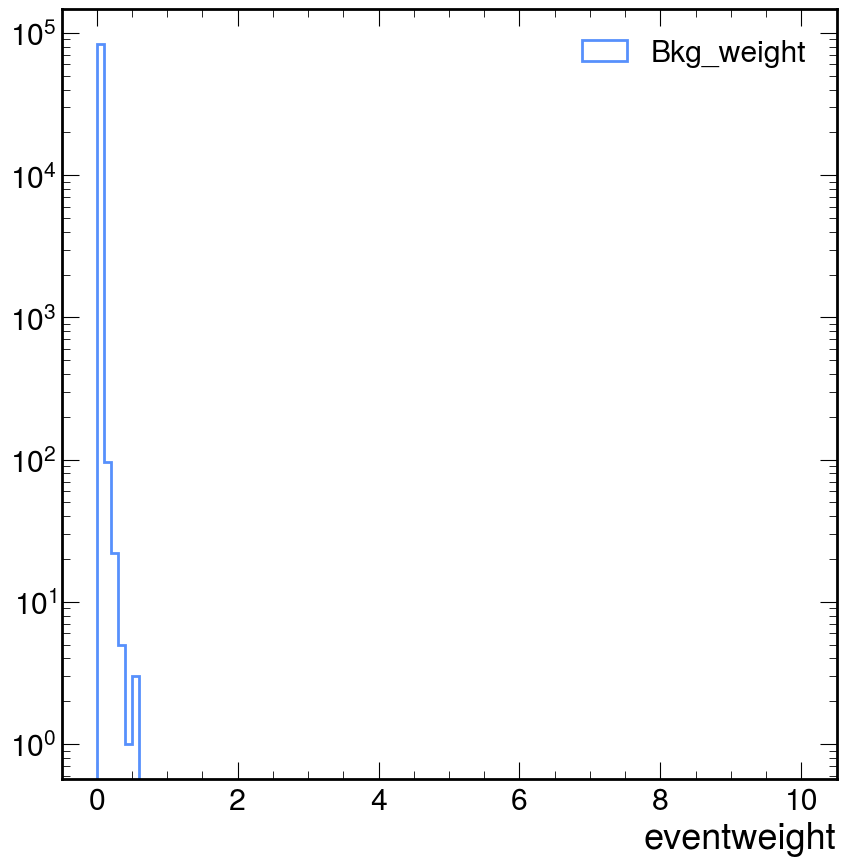

In [36]:
plt.hist(df_TT["eventWeight"], bins=100, range=(0,10), histtype = 'step', linewidth = 2, density=False,
         label="Bkg_weight")
plt.yscale("log")
plt.legend()
plt.xlabel("eventweight")
plt.show()

In [39]:
df_bkg = df_bkg[df_bkg["eventWeight"]<1].copy()

In [73]:
#control_variable

In [74]:
# # t-test 
# def t_value(r,n):
#     return r * np.sqrt(n-2) / np.sqrt(1-r**2)

In [75]:
# t_value(0.017552, 17814)

In [13]:
resample_list = ["b-tagging"]

In [92]:
arr_sig = np.repeat([1,2,3,4,5], [2913,1634,2081,3940,7227])

In [12]:
# 
resample_list = ["b-tagging","fatjet_selected_pnetmass"]

In [13]:
import random as random

In [14]:
source_mass = df_sig["fatjet_selected_pnetmass"].to_numpy()
source_btag = df_sig["b-tagging"].to_numpy()

In [15]:
# boostrap 
output_mass = []
output_btag = []
for i in range(len(df_bkg)):
    output_mass.append(random.choice(source_mass))
    output_btag.append(random.choice(source_btag))

In [16]:
df_sig_sample = pd.DataFrame({
    "b-tagging": output_btag,
    "fatjet_selected_pnetmass": output_mass
})

In [55]:
# boostrap 
# output_ggj=[]
# for i in range(len(df_bkg)):
#     output_ggj.append(random.choice(source))
# output_ggj = np.array(output_ggj)

In [56]:
#resample 1 columns
# def permute_columns(df: pd.DataFrame, cols: list[str], arr_sig:list[float], seed: int ):
#     rng = np.random.default_rng(seed)
#     out = df.copy()
#     n = len(out)

#     for col in cols:
#         perm = rng.permutation(n)
#         out[col] = arr_sig[perm]

#     return out

In [17]:
def permute_columns(df: pd.DataFrame, cols: list[str], arr_sig: pd.DataFrame, seed: int):
    rng = np.random.default_rng(seed)
    out = df.copy()
    n = len(out)

    for col in cols:
        perm = rng.permutation(n)
        out[col] = arr_sig[col].to_numpy()[perm]

    return out

In [18]:
def resample_score_concat(df_all: pd.DataFrame,
                          resample_list: list[str],
                          BDT_variables: list[str],
                          arr_sig: pd.DataFrame,
                          model,
                          K: int = 50,
                          seed0: int = 38,
                          output_margin: bool = False,
                          score_col: str = "bdt_score",
                          event_id_col: str | None = None,
                          keep: str = "max_score"   # "first" or "max_score"
                         ) -> pd.DataFrame:

    dfs = []

    for k in range(K):
        df_perm = permute_columns(df_all, resample_list, arr_sig, seed=seed0 + k).copy()

        # event id
        if event_id_col is None:
            df_perm["_event_id"] = df_all.index.to_numpy()
        else:
            df_perm["_event_id"] = df_all[event_id_col].to_numpy()

        # score
        X = df_perm[BDT_variables].to_numpy(dtype=np.float32)
        d = xgb.DMatrix(X)

        best_it = getattr(model, "best_iteration", None)
        if best_it is not None:
            p = model.predict(
                d,
                iteration_range=(0, best_it + 1),
                output_margin=output_margin
            )
        else:
            p = model.predict(d, output_margin=output_margin)

        df_perm[score_col] = p
        df_perm["resample_id"] = k

        dfs.append(df_perm[df_perm[score_col] > 0.7])

    if len(dfs) == 0:
        return pd.DataFrame(columns=list(df_all.columns) + ["_event_id", score_col, "resample_id"])

    df_big = pd.concat(dfs, ignore_index=True)

    # deduplicate: one row per original event
    if keep == "first":
        df_big = df_big.drop_duplicates(subset="_event_id", keep="first")
    elif keep == "max_score":
        df_big = df_big.sort_values(score_col, ascending=False)
        df_big = df_big.drop_duplicates(subset="_event_id", keep="first")
    else:
        raise ValueError("keep must be 'first' or 'max_score'")

    df_big = df_big.reset_index(drop=True)
    return df_big

In [19]:
df_resampled = resample_score_concat(
    df_all=df_bkg,
    resample_list=resample_list,
    BDT_variables=BDT_variables,
    arr_sig = df_sig_sample,
    model=models_A[0],
    K=1000
)

In [46]:
#df_TTG = df_resampled.copy()

In [60]:
#df_GGJ = df_resampled.copy()

In [64]:
#df_total_resample = pd.concat([df_GGJ,df_TTG],ignore_index = True)

In [65]:
#df_resampled = df_total_resample.copy()

In [20]:
model = models_A[0]

In [21]:
X = df_bkg[BDT_variables].to_numpy(dtype=np.float32)
d = xgb.DMatrix(X)


In [22]:
best_it = getattr(model, "best_iteration", None)

if best_it is not None:
    p = model.predict(
        d,
        iteration_range=(0, best_it + 1),
        output_margin=False
        )
else:
    p = model.predict(d, output_margin=False)

In [23]:
df_bkg["bdt_score"] = p

In [85]:

# plt.hist(df_resampled["b-tagging"], bins=5, range=(1,6), histtype = 'step', linewidth = 2, density=True,
#          weights=df_resampled["weight"], label="Original")
# plt.legend()
# plt.xlabel("Output")
# plt.show()

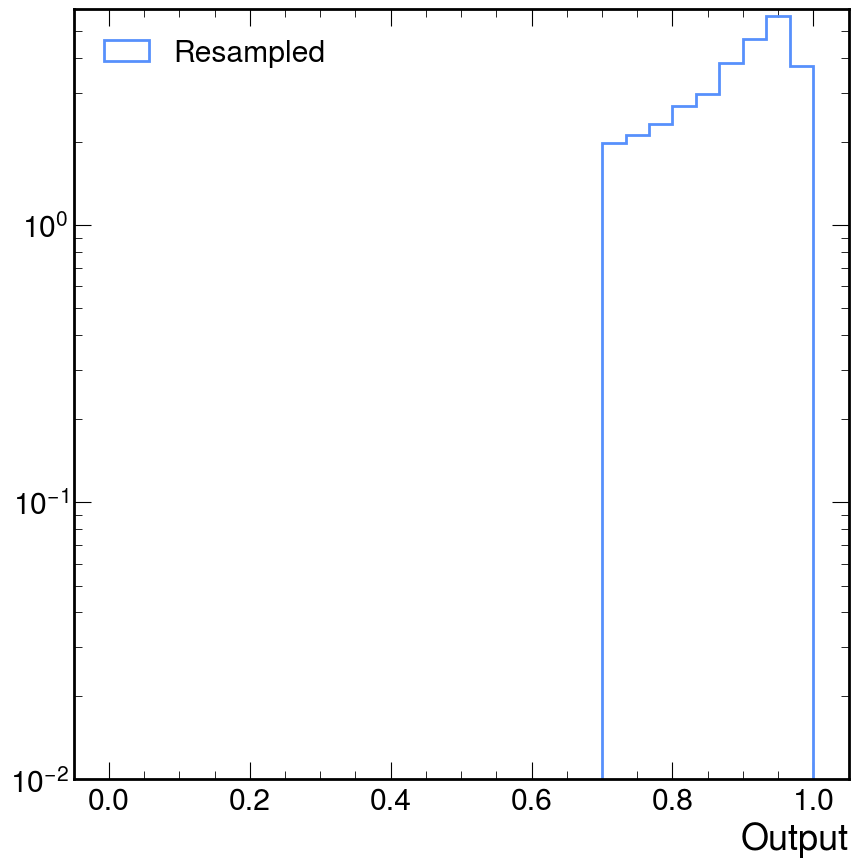

In [24]:
plt.hist(df_resampled["bdt_score"], bins=30, range=(0,1), histtype = 'step', linewidth = 2,density=True,
         weights=df_resampled["eventWeight"], label="Resampled")
# plt.hist(df_bkg["oof_score"], bins=30, range=(0,1), histtype = 'step', linewidth = 2, density=True,
#          weights=df_bkg["eventWeight"], label="Original")
plt.yscale("log")
plt.ylim(1e-2,)
plt.legend()
plt.xlabel("Output")
plt.show()

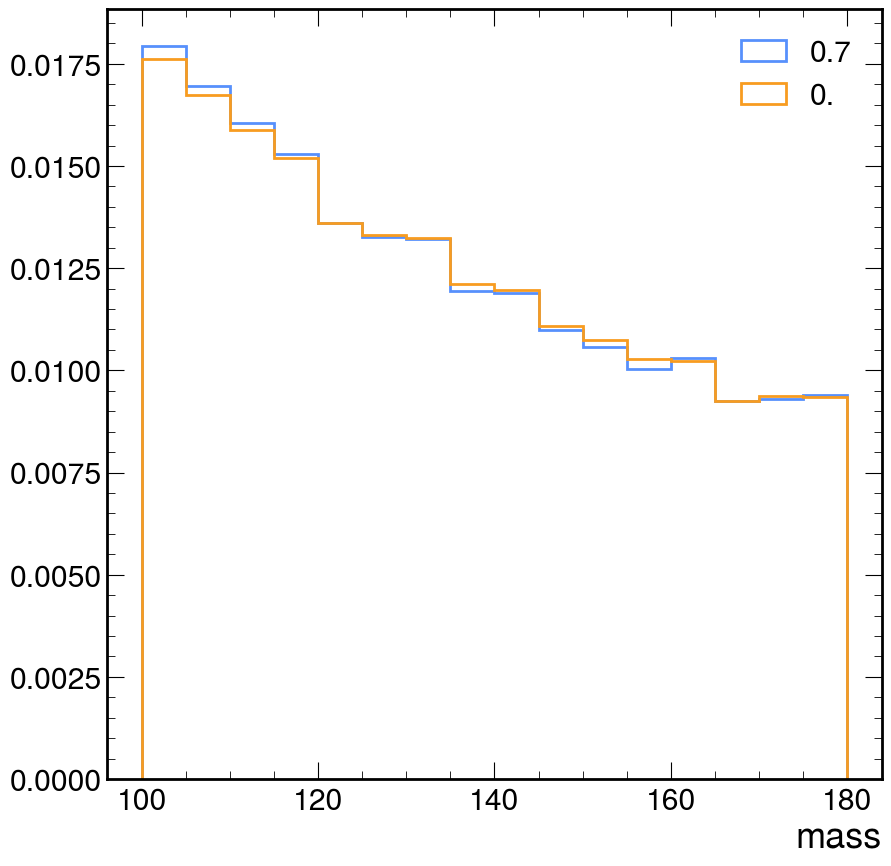

In [25]:
plt.hist(df_resampled[df_resampled["bdt_score"]>0.7]["mass"], bins=16, range=(100,180), histtype = 'step', linewidth = 2,density=True,
         weights=df_resampled[df_resampled["bdt_score"]>0.7]["eventWeight"], label="0.7")
plt.hist(df_bkg[df_bkg["bdt_score"]>0]["mass"], bins=16, range=(100,180), histtype = 'step', linewidth = 2,density=True,
         weights=df_bkg[df_bkg["bdt_score"]>0]["eventWeight"], label="0.")
plt.legend()
plt.xlabel("mass")
plt.show()

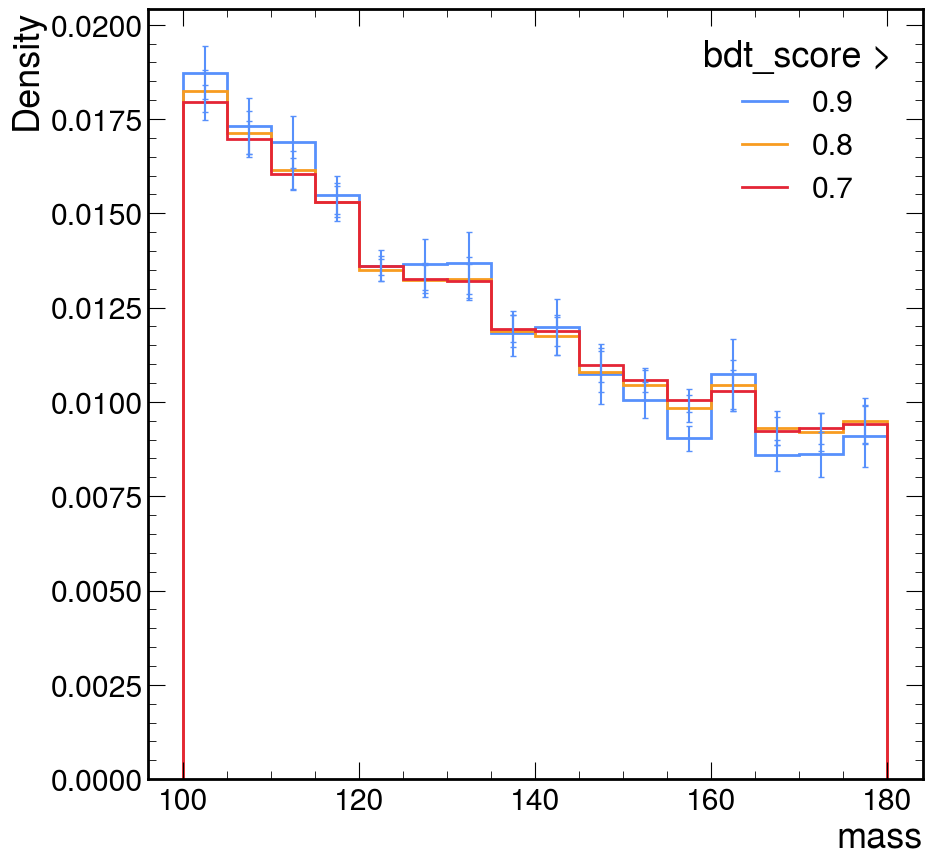

In [27]:
import numpy as np
import matplotlib.pyplot as plt

bins = 16
xrange = (100, 180)
thresholds = [0.9, 0.8, 0.7]

fig, ax = plt.subplots()

for thr in thresholds:
    mask = df_resampled["bdt_score"] > thr
    x = df_resampled.loc[mask, "mass"].to_numpy()
    w = df_resampled.loc[mask, "eventWeight"].to_numpy()

    # weighted histogram
    hist, edges = np.histogram(x, bins=bins, range=xrange, weights=w)
    sumw2, _ = np.histogram(x, bins=bins, range=xrange, weights=w**2)
    err = np.sqrt(sumw2)

    # convert to density=True convention
    bin_widths = np.diff(edges)
    norm = hist.sum()   # = sum of weights inside range

    hist_density = hist / (norm * bin_widths)
    err_density = err / (norm * bin_widths)

    centers = 0.5 * (edges[:-1] + edges[1:])

    ax.stairs(hist_density, edges, linewidth=2, label=f"{thr}")
    ax.errorbar(
        centers,
        hist_density,
        yerr=err_density,
        fmt="none",
        capsize=2
    )

ax.legend(title="bdt_score >")
ax.set_xlabel("mass")
ax.set_ylabel("Density")
plt.show()

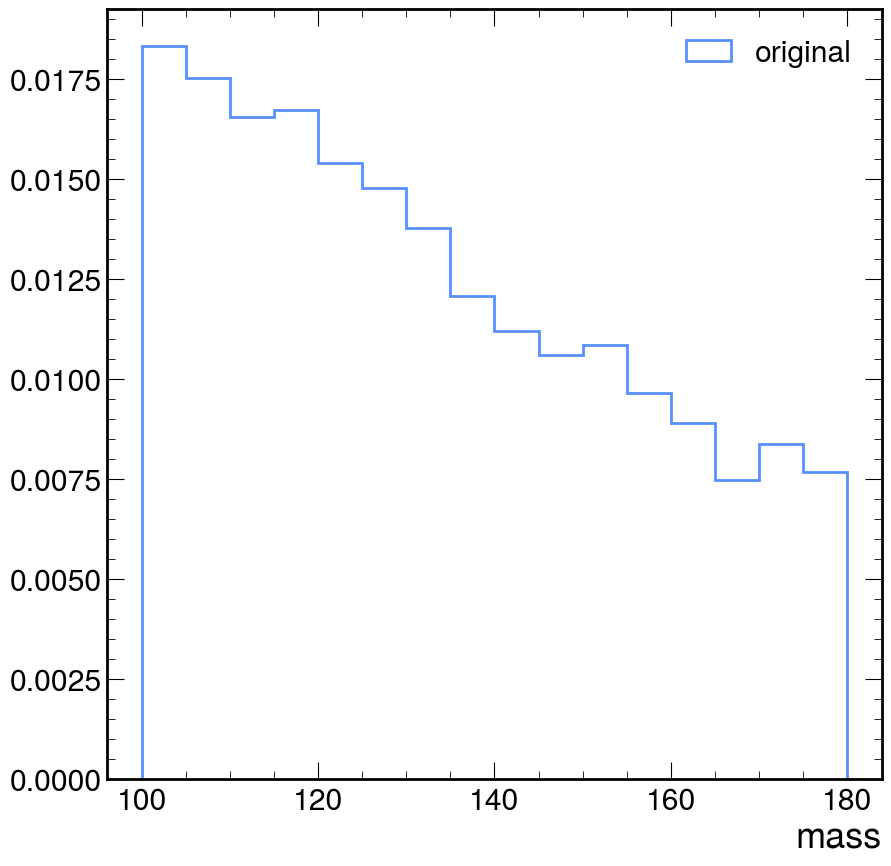

In [17]:
# plt.hist(df_bkg[df_bkg["oof_score"]>0.]["mass"], bins=16, range=(100,180), histtype = 'step', linewidth = 2,density=True,
#          weights=df_bkg[df_bkg["oof_score"]>0.]["eventWeight"], label="original")
# plt.hist(df_bkg[df_bkg["bdt_score"]>0.]["mass"], bins=16, range=(100,180), histtype = 'step', linewidth = 2,density=True,
#          weights=df_bkg[df_bkg["bdt_score"]>0.]["weight"], label="original")
# plt.hist(df_resampled[df_resampled["bdt_score"]>0.]["mass"], bins=16, range=(100,180), histtype = 'step', linewidth = 2,density=True,
#          weights=df_resampled[df_resampled["bdt_score"]>0.]["eventWeight"], label="resampled - 0.")
# plt.hist(df_resampled[df_resampled["bdt_score"]>0.7]["mass"], bins=20, range=(100,180), histtype = 'step', linewidth = 2,density=True,
#          weights=df_resampled[df_resampled["bdt_score"]>0.7]["eventWeight"], label="resampled - 0.7")
plt.legend()
plt.xlabel("mass")
plt.show()

4520


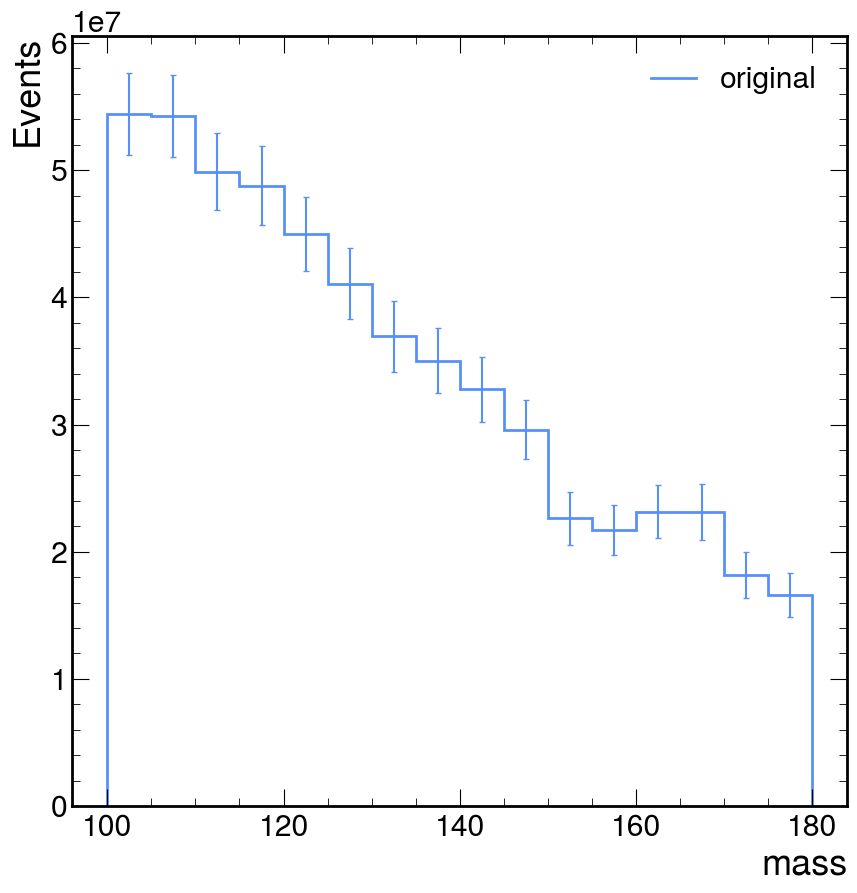

In [42]:
bins = 16
range_ = (100, 180)

fig, ax = plt.subplots()

# ===== original =====
mask = df_bkg["bdt_score"] > 0
x = df_bkg.loc[mask, "mass"].to_numpy()
w = df_bkg.loc[mask, "eventWeight"].to_numpy()
print(len(x))
hist1, edges = np.histogram(x, bins=bins, range=range_, weights=w)
sumw2_1, _ = np.histogram(x, bins=bins, range=range_, weights=w**2)
err1 = np.sqrt(sumw2_1)

centers = 0.5 * (edges[:-1] + edges[1:])

ax.stairs(hist1, edges, linewidth=2, label="original")
ax.errorbar(centers, hist1, yerr=err1, fmt='none', capsize=2)

# # ===== resampled =====
# mask = df_resampled["bdt_score"] > 0.7
# x = df_resampled.loc[mask, "mass"].to_numpy()
# w = df_resampled.loc[mask, "weight"].to_numpy()

# hist2, _ = np.histogram(x, bins=bins, range=range_, weights=w)
# sumw2_2, _ = np.histogram(x, bins=bins, range=range_, weights=w**2)
# err2 = np.sqrt(sumw2_2)

# ax.stairs(hist2, edges, linewidth=2, label="resampled")
# ax.errorbar(centers, hist2, yerr=err2, fmt='none', capsize=2)

ax.set_xlabel("mass")
ax.set_ylabel("Events")
ax.legend()
plt.show()